In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import metrics
from numpy import float32 
import time
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [9]:
data=pd.read_csv('denoised_spectra.csv')

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import umap

In [12]:
# 2. 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# # 1. 读取数据
# header = pd.read_csv('denoised_spectra.csv', nrows=0).columns.tolist()
# x_labels = np.array(header, dtype=float)
# df = pd.read_csv('denoised_spectra.csv', header=0)

# # 2. 标准化数据
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df)

# 3. UMAP降维
umap = UMAP(n_components=3,metric='euclidean')
embedding = umap.fit_transform(X_scaled)

# 4. 计算特征重要性（替代载荷）
# 方法1：通过特征与UMAP嵌入的相关性
feature_importance = np.array([
    np.corrcoef(X_scaled[:, i], embedding[:, 0])[0, 1]  # 与第一UMAP维度的相关系数
    for i in range(X_scaled.shape[1])
])

# 方法2：使用UMAP的特征重要性（需要安装umap-learn>=0.5.0）
# feature_importance = umap.feature_importances_  # 如果可用

# 5. 可视化
plt.figure(figsize=(10, 5))
plt.plot(x_labels, np.abs(feature_importance), color='blue', linewidth=1.5)  # 取绝对值
plt.title("Feature Importance via UMAP Correlation")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("UMAP Correlation (|Weight|)")
plt.xticks([200,400,600,800, 1000, 1200, 1400, 1600,1800,2000])
plt.grid(linestyle='--', alpha=0.6)
plt.show()


/home/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


NameError: name 'x_labels' is not defined

<Figure size 1000x500 with 0 Axes>

In [13]:
import umap
reducer = umap.UMAP(n_components=2,n_neighbors=15,random_state=42,metric='euclidean')
data_umap = reducer.fit_transform(X_scaled)


/home/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
from datetime import datetime

# 1. Prepare your data (replace with your actual data)
# data_umap should be your preprocessed data
# Example with random data if you don't have actual data:
# data_umap = np.random.rand(1000, 2)  # Example shape

# 2. Define K range to test
k_range = range(1, 11)  # Testing 1-10 clusters
sse = []  # To store sum of squared errors

# 3. Calculate SSE for different K values
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(data_umap)
    sse.append(kmeans.inertia_)  # inertia_ is SSE

# 4. Plot elbow curve with larger fonts
plt.figure(figsize=(12, 8))
plt.plot(k_range, sse, 'bo-', markersize=10, linewidth=3)

# Set font sizes to 20
plt.xticks(k_range, fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Number of clusters (K)', fontsize=20)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=20)
# plt.title('Elbow Method for Optimal K', fontsize=22, pad=20)

# 5. Mark suggested elbow point (automatically detected)
deltas = np.diff(sse) / sse[1:]  # Calculate rate of change
elbow_k = np.argmin(deltas) + 2  # +2 compensates for index offset
plt.axvline(x=elbow_k, color='r', linestyle='--', linewidth=3,
            label=f'Suggested K = {elbow_k}')

# Set legend with larger font
plt.legend(fontsize=18, framealpha=0.9)
plt.grid(True, alpha=0.3)



# 7. Save the plot with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = "Elbow.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# 8. Print suggested K value
print(f"\nSuggested optimal K (elbow point): {elbow_k}")


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


聚类标签： [2 1 1 1 1 2 2 2 2 2 2 4 2 2 4 1 1 1 1 1 0 0 0 0 0 0 4 2 2 0 2 4 0 0 0 3 3
 3 3 3 3 0 3 0 0 3 0 1 2 4 0 4 3 3 3 0 4 1 0 1 3 3 3 3 3 2 3 4 2 1 3 0 0 3
 4 4 3 3 3 4 0 4 4 1 2 4 4 1 0 4 2 0 0 4 0 4 2 0 4 1 0 0 2 0 4 2 1 2 2 2 2
 2 2 2 2 2 1 1 1 1 1 4 4 1 1 4 1 0 2 1 3 0 0 1 2 1 2 3 3 4 0 3 0 4 0 1 0 3
 3]
聚类中心： [[ 6.777015   1.5655112]
 [-1.1989908  2.6439824]
 [ 1.2958264  3.6955042]
 [ 8.879875   2.048229 ]
 [ 4.178866   2.1477478]]


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

图片已保存至: UMAP_kmeans_clustering.jpg


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

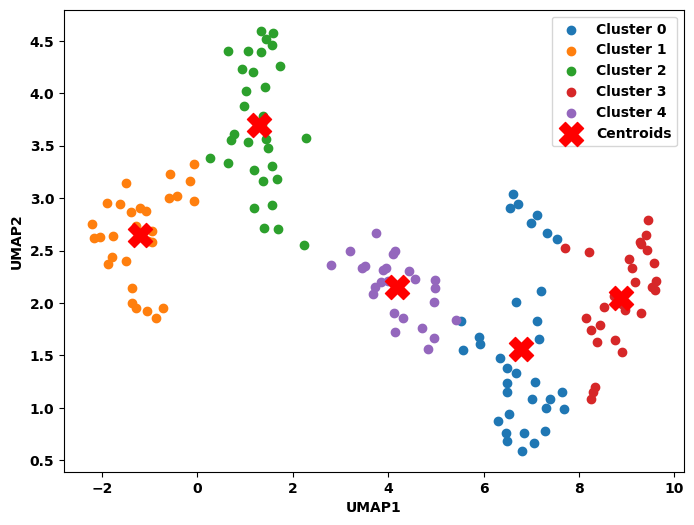

0.5797501
Calinski-Harabasz指数: 849.47156


In [126]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.weight'] = 'bold'  # 全局加粗
# plt.rcParams['axes.labelweight'] = 'bold'  # 坐标轴标签加粗

# 选择聚类的数量 k
# 这里我们假设 k=3，你可以根据实际情况调整
k = 5

# 创建 KMeans 模型
kmeans = KMeans(n_clusters=k)

# 拟合模型
kmeans.fit(data_umap)

# 获取聚类结果
labels = kmeans.labels_  # 每个样本的聚类标签
centroids = kmeans.cluster_centers_  # 聚类中心

# 打印聚类结果
print("聚类标签：", labels)
print("聚类中心：", centroids)

plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(data_umap[labels == i, 0], data_umap[labels == i, 1], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
# plt.title("K-Means Clustering1")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
save_path="UMAP_kmeans_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"图片已保存至: {save_path}")
plt.show()
from sklearn.metrics import silhouette_score
print(silhouette_score(data_umap, kmeans.labels_))  # 值越接近1越好‌:ml-citation{ref="3,7" data="citationList"}
print("Calinski-Harabasz指数:", calinski_harabasz_score(data_umap, labels))


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

评估图表已保存至: k_values_evaluation.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

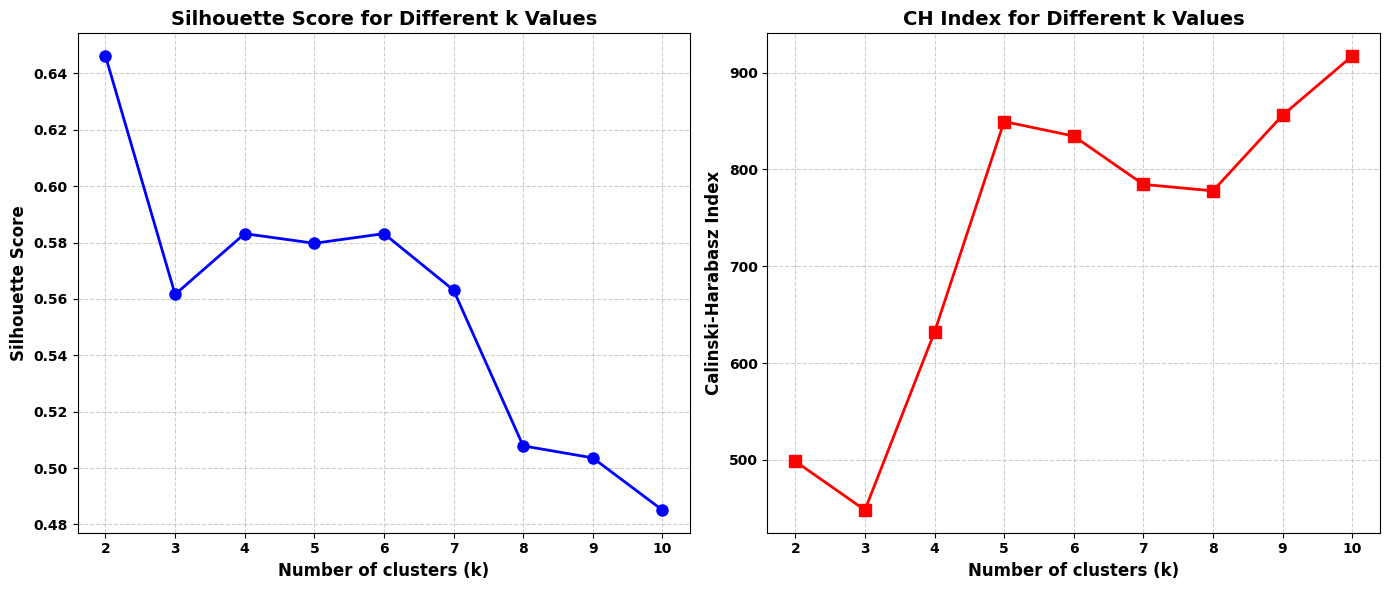


评估指标数值:
k=2: Silhouette Score = 0.6462, CH Index = 498.5175
k=3: Silhouette Score = 0.5616, CH Index = 448.2445
k=4: Silhouette Score = 0.5832, CH Index = 632.0231
k=5: Silhouette Score = 0.5798, CH Index = 849.4716
k=6: Silhouette Score = 0.5832, CH Index = 834.4579
k=7: Silhouette Score = 0.5631, CH Index = 784.5519
k=8: Silhouette Score = 0.5079, CH Index = 777.8778
k=9: Silhouette Score = 0.5036, CH Index = 855.9600
k=10: Silhouette Score = 0.4851, CH Index = 917.1147


In [109]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 设置全局字体为Times New Roman并加粗
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 定义k值范围
k_range = range(2, 11)
silhouette_scores = []
ch_scores = []

# 计算不同k值的评估指标
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_umap)
    
    # 计算轮廓系数
    silhouette_scores.append(silhouette_score(data_umap, kmeans.labels_))
    
    # 计算CH指数
    ch_scores.append(calinski_harabasz_score(data_umap, kmeans.labels_))

# 创建画布和子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 绘制轮廓系数图
ax1.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of clusters (k)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score for Different k Values', fontsize=14, weight='bold')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# 绘制CH指数图
ax2.plot(k_range, ch_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of clusters (k)', fontsize=12)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=12)
ax2.set_title('CH Index for Different k Values', fontsize=14, weight='bold')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

# 调整布局并保存
plt.tight_layout()
save_path = "k_values_evaluation.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"评估图表已保存至: {save_path}")
plt.show()

# 打印具体数值
print("\n评估指标数值:")
for i, k in enumerate(k_range):
    print(f"k={k}: Silhouette Score = {silhouette_scores[i]:.4f}, CH Index = {ch_scores[i]:.4f}")


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

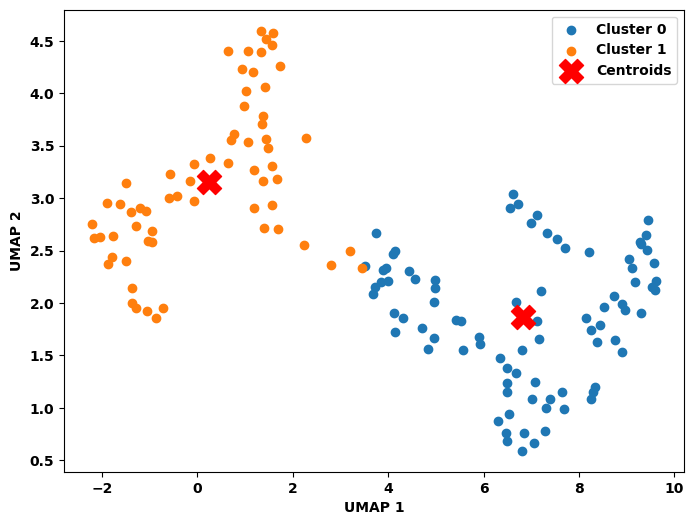

轮廓系数: 0.6462
Calinski-Harabasz指数: 498.5175

=== 簇信息统计 ===

簇 0 信息:
样本数量: 85
在UMAP空间中的中心位置: [6.833561  1.8663048]
特征统计信息:
               0          1
count  85.000000  85.000000
mean    6.833561   1.866305
std     1.826100   0.617262
min     3.512290   0.590512
25%     5.425417   1.478322
50%     6.995379   1.903880
75%     8.345408   2.331243
max     9.611632   3.038610

簇 1 信息:
样本数量: 64
在UMAP空间中的中心位置: [0.2522924 3.1583238]
特征统计信息:
               0          1
count  64.000000  64.000000
mean    0.252292   3.158324
std     1.476163   0.744072
min    -2.202432   1.855464
25%    -1.106559   2.625175
50%     0.680650   3.012020
75%     1.399795   3.581325
max     3.444726   4.596537


In [128]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 假设 data_umap 是你的数据
k = 2
kmeans = KMeans(n_clusters=k)
kmeans.fit(data_umap)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 可视化聚类结果
plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(data_umap[labels == i, 0], data_umap[labels == i, 1], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
save_path = "UMAP_kmeans_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

# 打印聚类评估指标
print(f"轮廓系数: {silhouette_score(data_umap, kmeans.labels_):.4f}")
print(f"Calinski-Harabasz指数: {calinski_harabasz_score(data_umap, labels):.4f}")

# 打印每个簇的详细信息
print("\n=== 簇信息统计 ===")
for i in range(k):
    cluster_data = data_umap[labels == i]
    print(f"\n簇 {i} 信息:")
    print(f"样本数量: {len(cluster_data)}")
    print(f"在UMAP空间中的中心位置: {centroids[i]}")
    print("特征统计信息:")
    print(pd.DataFrame(cluster_data).describe())
    
    # 如果你有原始数据，可以添加更多统计信息
    # 例如：print(pd.DataFrame(original_data[labels == i]).describe())


In [129]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=int32)

In [130]:
import pandas as pd
# 转换为DataFrame并保存为CSV
df = pd.DataFrame({'Label': labels})
df.to_csv('labels_UMAP2.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


/home/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


图片已保存至: UMAP_kmeans_clustering.jpg


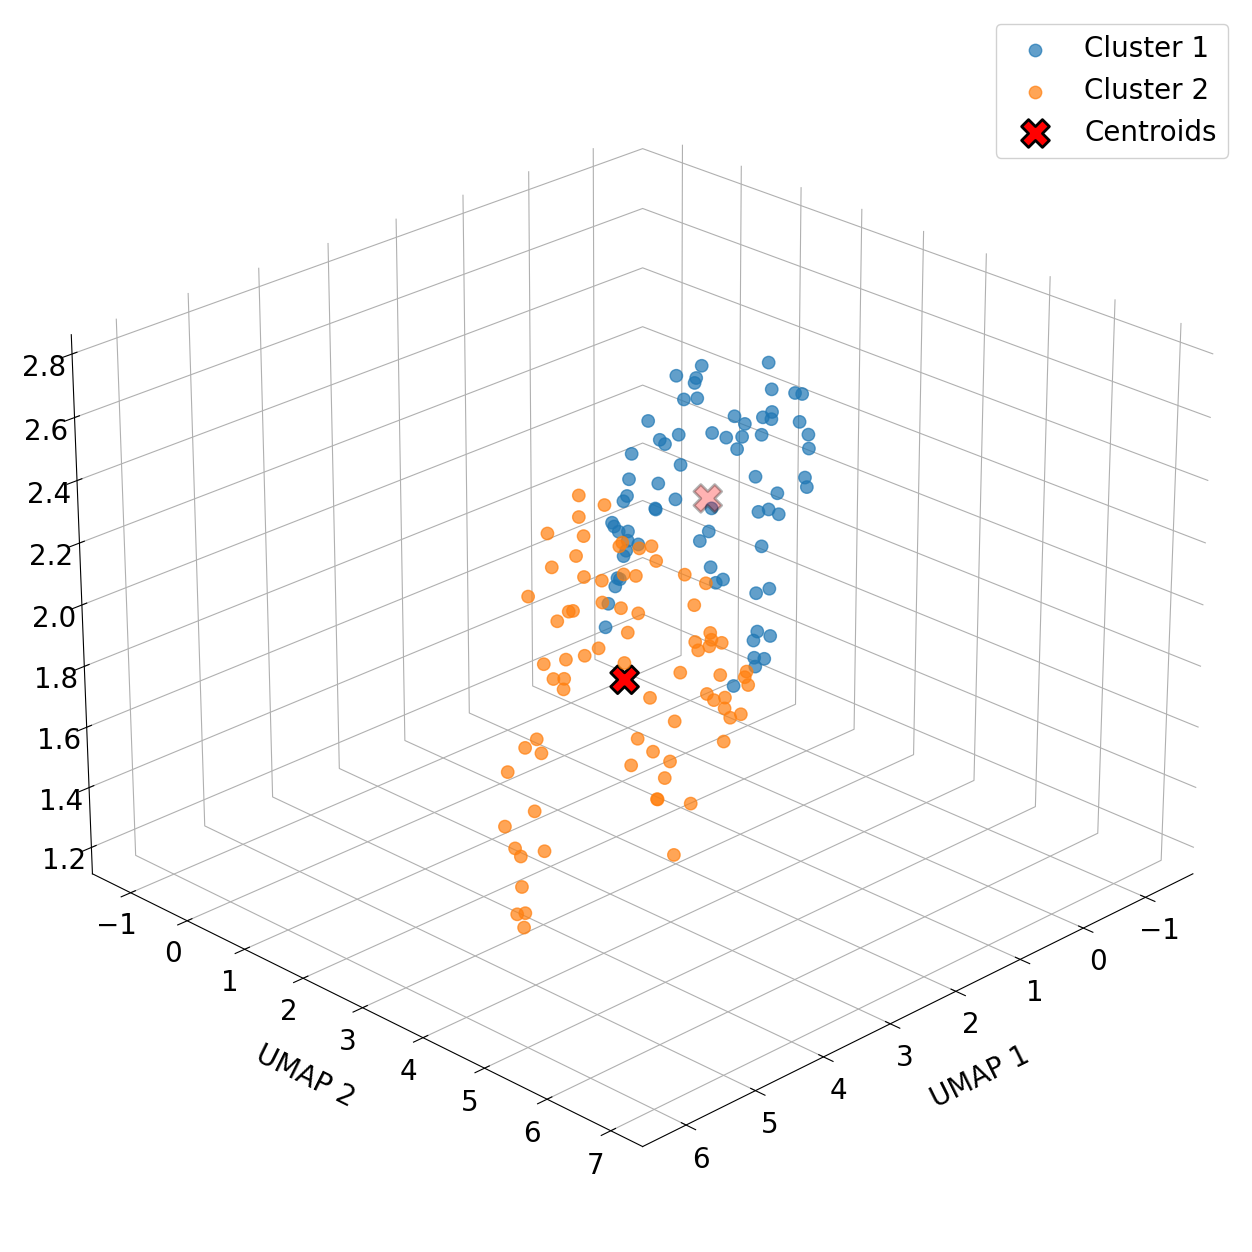

Silhouette Score: 0.607 (越接近1越好)
Calinski-Harabasz指数: 419.408


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from umap import UMAP
import matplotlib as mpl

# Set global font sizes
mpl.rcParams.update({
    'legend.fontsize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'axes.titlesize': 20
})

# UMAP dimensionality reduction to 3D
reducer = UMAP(n_components=3, random_state=42, metric='euclidean')
data_umap_3d = reducer.fit_transform(X_scaled)

# K-Means clustering (k=2)
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data_umap_3d)
centroids = kmeans.cluster_centers_

# 3D visualization
fig = plt.figure(figsize=(18, 16))  # Increased figure size
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster with larger markers
for i in range(k):
    ax.scatter(
        data_umap_3d[labels == i, 0],
        data_umap_3d[labels == i, 1],
        data_umap_3d[labels == i, 2],
        label=f'Cluster {i+1}',  # Changed to 1-based indexing
        alpha=0.7,
        s=80  # Increased marker size
    )

# Plot centroids with larger markers
ax.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=400, c='red', marker='X', label='Centroids',
    edgecolor='black', linewidth=2
)

# Set axis labels with fontsize 20
# ax.set_title('3D UMAP Projection with K-Means Clustering (k=2)', fontsize=22, pad=20)
ax.set_xlabel('UMAP 1', fontsize=20, labelpad=20)
ax.set_ylabel('UMAP 2', fontsize=20, labelpad=20)
ax.set_zlabel('UMAP 3', fontsize=20, labelpad=20)

# Set legend with larger font
ax.legend(fontsize=20, framealpha=0.9)

# Adjust view angle
ax.view_init(elev=25, azim=45)

# Set background to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Save high-quality image
save_path = "UMAP_kmeans_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"图片已保存至: {save_path}")

plt.show()

# Evaluation metrics
silhouette_avg = silhouette_score(data_umap_3d, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print(f"Calinski-Harabasz指数: {calinski_harabasz_score(data_umap_3d, labels):.3f}")


聚类标签： [1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 0]


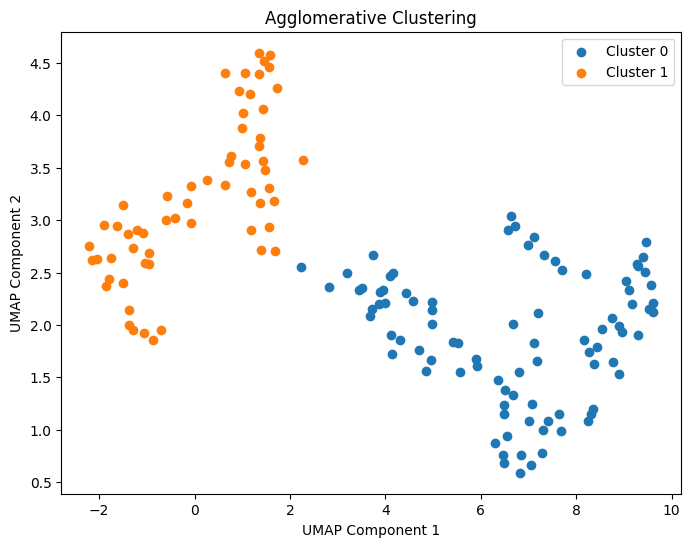

图片已保存至: UMAP_Ceng_clustering.jpg


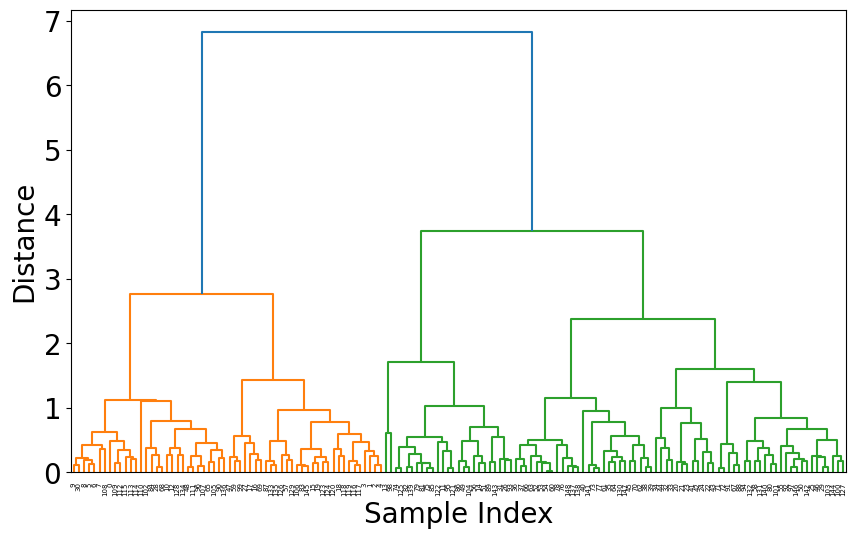

Silhouette Score: 0.640 (越接近1越好)
Calinski-Harabasz指数: 464.1921


In [28]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA



# 选择聚类的数量
# 这里我们假设 k=3，你可以根据实际情况调整
k = 2

# 创建层次聚类模型
agglo = AgglomerativeClustering(n_clusters=k, linkage='average')

# 拟合模型
agglo.fit(data_umap)

# 获取聚类结果
labels = agglo.labels_  # 每个样本的聚类标签

# 打印聚类结果
print("聚类标签：", labels)

plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(data_umap[labels == i, 0], data_umap[labels == i, 1], label=f'Cluster {i}')
plt.title("Agglomerative Clustering")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.show()

# 绘制层次聚类的树状图（Dendrogram）
plt.figure(figsize=(10, 6))
dendrogram(linkage(data_umap, method='average'))
# plt.title("Dendrogram", fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Sample Index", fontsize=20)
plt.ylabel("Distance", fontsize=20)

# Save high-quality image
save_path = "UMAP_Ceng_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"图片已保存至: {save_path}")

plt.show()
silhouette_avg = silhouette_score(data_umap, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(data_umap, labels))


In [ ]:
# import pandas as pd
# # 转换为DataFrame并保存为CSV
# df = pd.DataFrame({'Label': labels})
# df.to_csv('labels_umap_Cengcluster7.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


In [ ]:
# import pandas as pd
# # 转换为DataFrame并保存为CSV
# df = pd.DataFrame({'Label': labels})
# df.to_csv('labels.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


In [27]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 生成一些数据

# 创建并拟合GMM模型
gmm = GaussianMixture(n_components=3, covariance_type='full')
gmm.fit(data_umap)

# 预测每个样本的类别
labels = gmm.predict(data_umap)




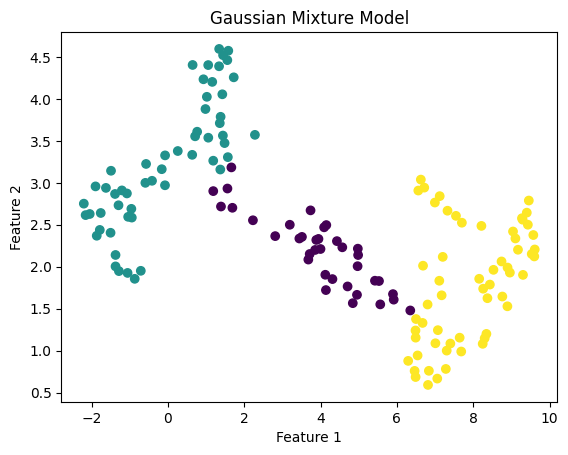

In [28]:
# 绘制结果
plt.scatter(data_umap[:, 0], data_umap[:, 1], c=labels, cmap='viridis', marker='o')
plt.title('Gaussian Mixture Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


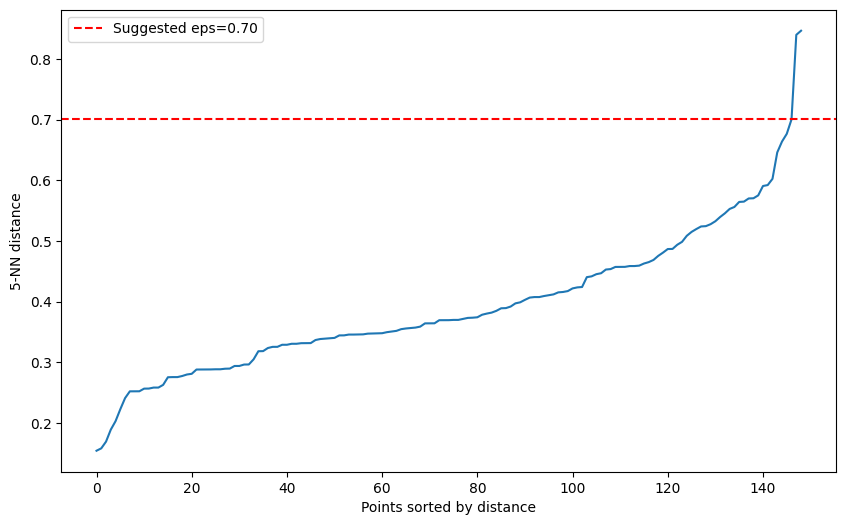

In [48]:
from sklearn.neighbors import NearestNeighbors

def find_dbscan_eps(data, min_pts):
    """
    通过k-距离图确定DBSCAN的eps参数
    :param data: 输入数据（需预先标准化）
    :param min_pts: 最小邻域点数（通常取维度+1）
    :return: 建议的eps值
    """
    neigh = NearestNeighbors(n_neighbors=min_pts)
    neigh.fit(data_umap)
    distances, _ = neigh.kneighbors(data_umap)
    k_distances = np.sort(distances[:, -1])
    
    # 自动检测拐点（最大曲率点）
    gradients = np.gradient(k_distances)
    elbow_idx = np.argmax(gradients)
    eps = k_distances[elbow_idx]
    
    # 可视化
    plt.figure(figsize=(10,6))
    plt.plot(k_distances)
    plt.axhline(y=eps, color='r', linestyle='--', 
                label=f'Suggested eps={eps:.2f}')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{min_pts}-NN distance')
    plt.legend()
    plt.show()
    
    return eps

# 使用示例
eps = find_dbscan_eps(data_umap, min_pts=5)  # 输出建议eps值


图片已保存至: UMAP_DBSCAN_clustering.jpg


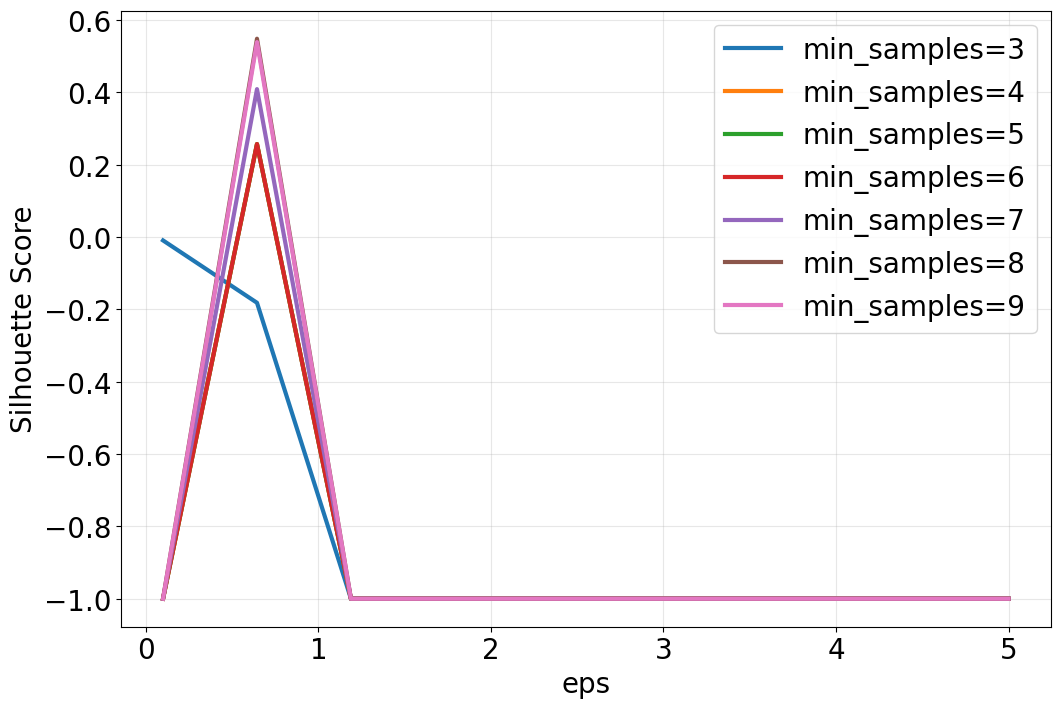

最佳eps: 0.64
最佳min_samples: 8
最佳轮廓系数: 0.548


In [21]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 网格搜索DBSCAN参数
eps_range = np.linspace(0.1, 5, 10)
min_samples_range = range(3, 10)
results = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data_umap)
        
        if len(set(labels)) > 1:
            score = silhouette_score(data_umap, labels)
            results.append((eps, min_samples, score))
        else:
            results.append((eps, min_samples, -1))

results = np.array(results)

# 可视化（字号全20）
plt.figure(figsize=(12, 8))
for min_samples in min_samples_range:
    filtered_results = results[results[:, 1] == min_samples]
    plt.plot(filtered_results[:, 0], filtered_results[:, 2], 
             linewidth=3,
             label=f'min_samples={min_samples}')

plt.xlabel('eps', fontsize=20)
plt.ylabel('Silhouette Score', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20, framealpha=0.8)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=20)
# Save high-quality image
save_path = "UMAP_DBSCAN_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"图片已保存至: {save_path}")
plt.show()

# 输出最佳参数
best_index = np.argmax(results[:, 2])
best_params = results[best_index]
print(f'最佳eps: {best_params[0]:.2f}\n'
      f'最佳min_samples: {int(best_params[1])}\n'
      f'最佳轮廓系数: {best_params[2]:.3f}')


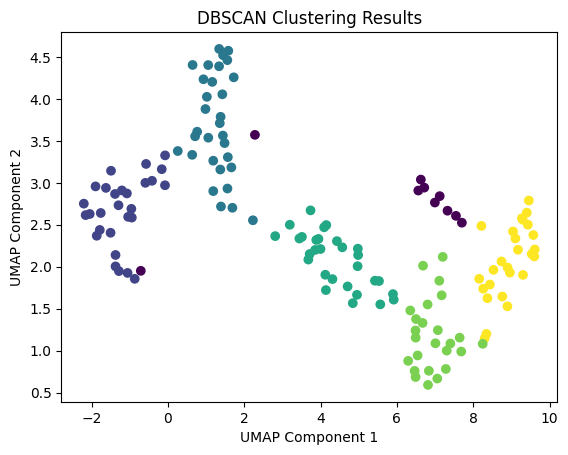

Silhouette Score: 0.548 (越接近1越好)
Calinski-Harabasz指数: 398.54193


In [79]:
# 导入必要的库
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
# 应用DBSCAN聚类
dbscan = DBSCAN(eps=0.644, min_samples=8)
clusters = dbscan.fit_predict(data_umap)

# 可视化聚类结果
#plt.scatter(PCA_ds[:, 0], PCA_ds[:, 1], c=clusters, cmap='viridis', marker='o')
plt.scatter(data_umap[:, 0], data_umap[:, 1], c=clusters, cmap='viridis', marker='o')

plt.title('DBSCAN Clustering Results')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()
silhouette_avg = silhouette_score(data_umap, clusters)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(data_umap, clusters))


In [80]:
clusters

array([ 1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  2,  1,  1,  2,  0,  0,
        0,  0,  0, -1, -1, -1, -1, -1,  3,  2,  1,  1,  3,  1,  2,  3,  3,
        3,  4,  4,  4,  4,  4,  4, -1, -1, -1,  3,  4,  3,  0,  1,  2,  3,
        2,  4,  4,  4,  3,  2, -1,  3,  0,  4,  4,  4,  4,  4,  1,  4,  2,
        1,  0,  4,  2,  2,  4,  2,  2,  4,  4,  4,  2,  3,  2,  2,  0,  1,
        2,  2,  0,  2,  2,  1,  2,  3,  2,  3,  2,  1,  3,  2,  0,  3,  3,
        1,  3,  2,  1,  0,  1,  1,  1, -1,  1,  1,  1,  1,  1,  0,  0,  0,
        0,  0,  2,  2,  0,  0,  2,  0,  3,  1,  0,  4,  3,  3,  0,  1,  0,
        1,  4,  4,  2,  3,  3,  3,  2,  3,  0,  3,  4,  4])

In [ ]:
import pandas as pd
# 转换为DataFrame并保存为CSV
df = pd.DataFrame({'Label': clusters})
df.to_csv('labels_UMAP_DBSCAN.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


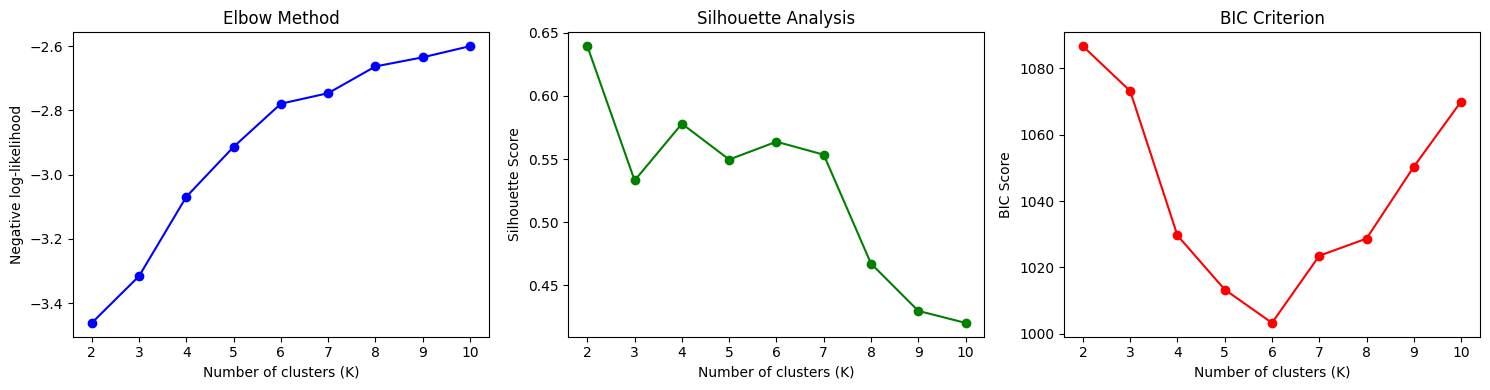

Best K based on BIC: 6


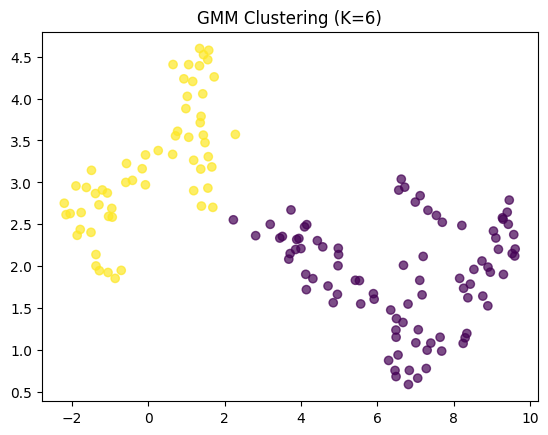

Silhouette Score: 0.640 (越接近1越好)
Calinski-Harabasz指数: 464.1921


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# 定义K值搜索范围
K_range = range(2, 11)

# 方法1：肘部法则（基于inertia_）
inertias = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_umap)
    inertias.append(gmm.lower_bound_)  # 负对数似然（越小越好）

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Negative log-likelihood')
plt.title('Elbow Method')

# 方法2：轮廓系数
silhouette_scores = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(data_umap)
    if len(np.unique(labels)) < 2:  # 至少需要2个聚类才能计算
        silhouette_scores.append(-1)
    else:
        silhouette_scores.append(silhouette_score(data_umap, labels))

plt.subplot(132)
plt.plot(K_range, silhouette_scores, 'go-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

# 方法3：BIC准则（越小越好）
bic_scores = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_umap)
    bic_scores.append(gmm.bic(data_umap))

plt.subplot(133)
plt.plot(K_range, bic_scores, 'ro-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('BIC Score')
plt.title('BIC Criterion')

plt.tight_layout()
plt.show()

# 自动选择最佳K值（以BIC为例）
best_k = K_range[np.argmin(bic_scores)]
print(f"Best K based on BIC: {best_k}")

# 用最佳K值训练最终模型
best_gmm = GaussianMixture(n_components=2, random_state=42)
best_gmm.fit(data_umap)
labels = best_gmm.predict(data_umap)

# 可视化聚类结果
plt.scatter(data_umap[:, 0],data_umap[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'GMM Clustering (K={best_k})')
plt.show()
silhouette_avg = silhouette_score(data_umap, labels)
print(f"Silhouette Score: {silhouette_avg:.3f} (越接近1越好)")
print("Calinski-Harabasz指数:", calinski_harabasz_score(data_umap, labels))


图片已保存至: UMAP_GMM_clustering.jpg


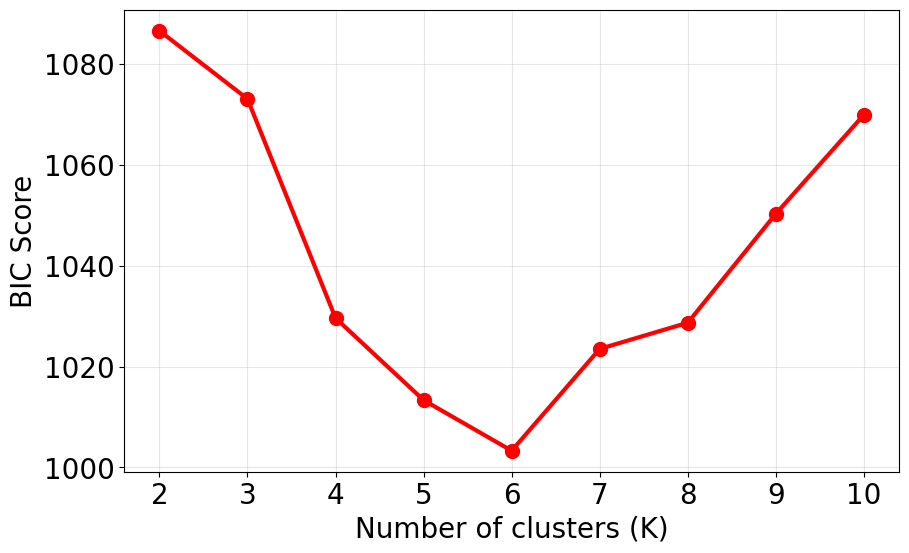

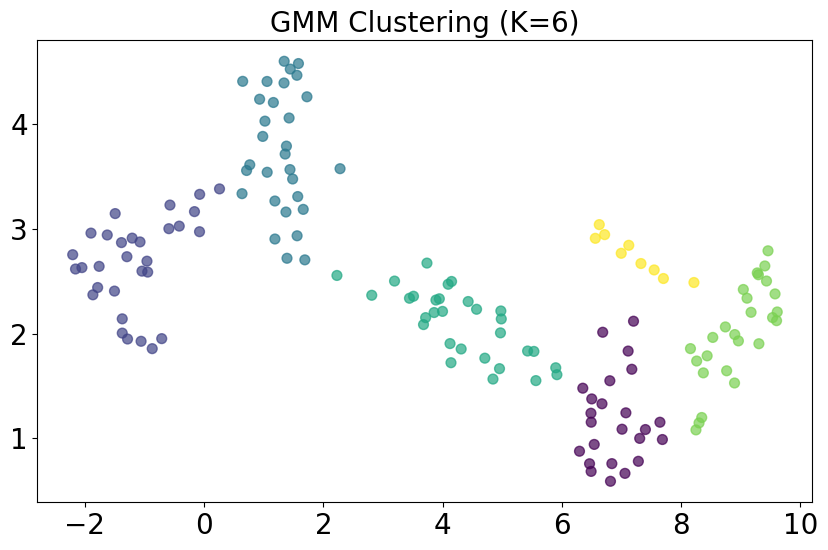

Silhouette Score: 0.564
Calinski-Harabasz Index: 740.3


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 1. BIC准则计算
K_range = range(2, 11)
bic_scores = [GaussianMixture(n_components=k, random_state=42).fit(data_umap).bic(data_umap) 
              for k in K_range]

# 2. BIC曲线可视化（字号20）
plt.figure(figsize=(10, 6))
plt.plot(K_range, bic_scores, 'ro-', markersize=10, linewidth=3)
plt.xticks(K_range, fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Number of clusters (K)', fontsize=20)
plt.ylabel('BIC Score', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=20)
# Save high-quality image
save_path = "UMAP_GMM_clustering.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"图片已保存至: {save_path}")
plt.show()

# 3. 选择最佳K值并聚类
best_k = K_range[np.argmin(bic_scores)]
gmm = GaussianMixture(n_components=best_k, random_state=42)
labels = gmm.fit_predict(data_umap)

# 4. 聚类结果可视化（字号20）
plt.figure(figsize=(10, 6))
plt.scatter(data_umap[:, 0], data_umap[:, 1], c=labels, 
            cmap='viridis', alpha=0.7, s=50)
plt.title(f'GMM Clustering (K={best_k})', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.show()

# 5. 输出评估指标
print(f"Silhouette Score: {silhouette_score(data_umap, labels):.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(data_umap, labels):.1f}")


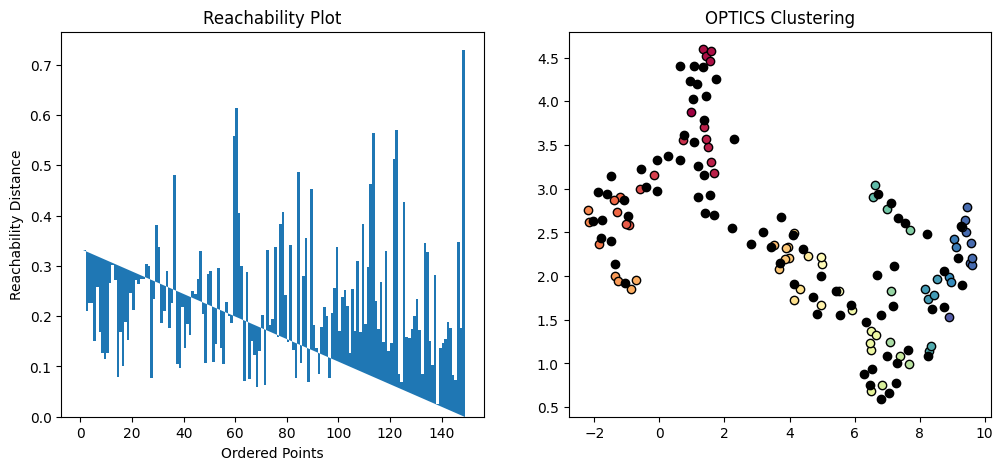

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

class OPTICS:
    def __init__(self, min_samples=5, max_eps=np.inf):
        self.min_samples = min_samples  # 核心点的最小邻居数
        self.max_eps = max_eps          # 邻域搜索的最大半径
        self.reachability_ = None       # 可达距离列表
        self.ordering_ = None           # 处理顺序
        self.core_dists_ = None         # 核心距离列表

    def fit(self, X):
        n = X.shape[0]
        self.reachability_ = np.full(n, np.inf)
        self.core_dists_ = np.full(n, np.nan)
        processed = np.zeros(n, dtype=bool)
        ordering = []

        # 计算距离矩阵（实际应用中可以使用空间索引优化）
        dist_matrix = np.sqrt(((X[:, np.newaxis] - X) ** 2).sum(axis=2))

        for i in range(n):
            if processed[i]:
                continue

            # 获取邻域内的点
            dists = dist_matrix[i]
            neighbors = np.where(dists <= self.max_eps)[0]
            neighbors = neighbors[np.argsort(dists[neighbors])]

            if len(neighbors) >= self.min_samples:
                self.core_dists_[i] = dists[neighbors[self.min_samples-1]]
            else:
                continue  # 非核心点

            processed[i] = True
            ordering.append(i)
            priority_queue = []

            # 更新可达距离
            for j in neighbors:
                if not processed[j]:
                    new_reach = max(self.core_dists_[i], dists[j])
                    if new_reach < self.reachability_[j]:
                        self.reachability_[j] = new_reach

            # 初始化优先队列
            self._update_priority_queue(priority_queue, neighbors, processed)

            # 处理优先队列
            while priority_queue:
                current = self._pop_priority_queue(priority_queue)
                if processed[current]:
                    continue

                dists_current = dist_matrix[current]
                neighbors_current = np.where(dists_current <= self.max_eps)[0]
                neighbors_current = neighbors_current[np.argsort(dists_current[neighbors_current])]

                if len(neighbors_current) >= self.min_samples:
                    self.core_dists_[current] = dists_current[neighbors_current[self.min_samples-1]]
                    processed[current] = True
                    ordering.append(current)

                    # 更新可达距离
                    for j in neighbors_current:
                        if not processed[j]:
                            new_reach = max(self.core_dists_[current], dists_current[j])
                            if new_reach < self.reachability_[j]:
                                self.reachability_[j] = new_reach

                    self._update_priority_queue(priority_queue, neighbors_current, processed)
                else:
                    processed[current] = True
                    ordering.append(current)

            self.ordering_ = ordering
        return self

    def _update_priority_queue(self, queue, neighbors, processed):
        for j in neighbors:
            if not processed[j] and not np.isinf(self.reachability_[j]):
                if (self.reachability_[j], j) not in queue:
                    # 使用堆结构维护优先队列
                    from heapq import heappush
                    heappush(queue, (self.reachability_[j], j))

    def _pop_priority_queue(self, queue):
        from heapq import heappop
        return heappop(queue)[1]

    def extract_clusters(self, xi=0.05):
        clusters = []
        current_cluster = []
        for i in self.ordering_:
            if self.reachability_[i] <= xi:
                if self.core_dists_[i] <= xi:  # 核心点
                    current_cluster.append(i)
                else:  # 边界点
                    current_cluster.append(i)
            else:
                if current_cluster:
                    clusters.append(current_cluster)
                    current_cluster = []
        if current_cluster:
            clusters.append(current_cluster)
        
        # 转换为标签
        labels = -np.ones(len(self.ordering_), dtype=int)
        for cluster_id, cluster in enumerate(clusters):
            labels[cluster] = cluster_id
        return labels

# # 生成示例数据
# X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)
# X = StandardScaler().fit_transform(X)

# # 添加一些噪声
# np.random.seed(0)
# X = np.concatenate([X, np.random.uniform(low=-3, high=3, size=(20, 2))])

# 运行OPTICS
optics = OPTICS(min_samples=2, max_eps=5)
optics.fit(data_umap)
labels = optics.extract_clusters(xi=0.2)

# 可视化结果
plt.figure(figsize=(12, 5))

# 可达距离图
plt.subplot(121)
plt.stairs(optics.reachability_[optics.ordering_], fill=True)
plt.title('Reachability Plot')
plt.xlabel('Ordered Points')
plt.ylabel('Reachability Distance')

# 聚类结果
plt.subplot(122)
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = (0, 0, 0, 1)  # 黑色表示噪声
    class_member_mask = (labels == k)
    xy = data_umap[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)
plt.title('OPTICS Clustering')
plt.show()

轮廓系数: 0.64592564
Calinski-Harabasz指数: 483.0428


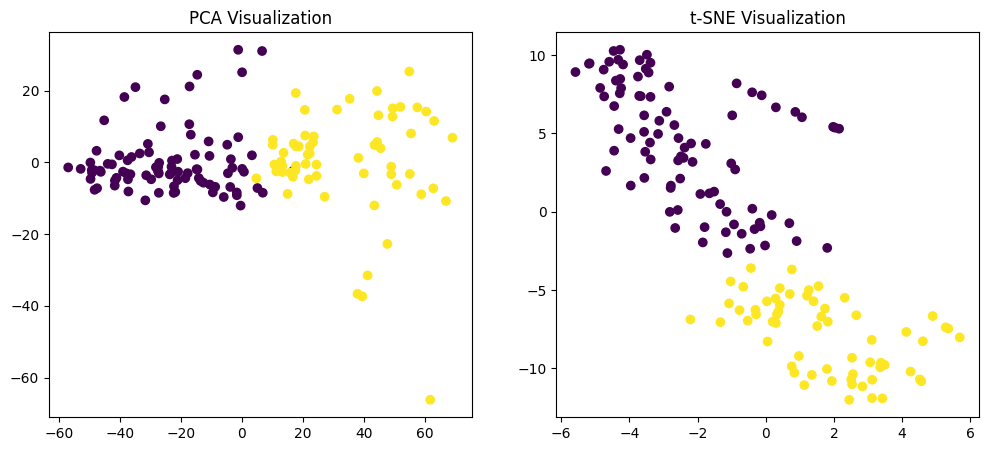

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
# ----------------------
# 谱聚类
# ----------------------
n_clusters = 2  # 根据实际情况调整（可通过肘部法则确定）

model = SpectralClustering(
    n_clusters=n_clusters,
    affinity='rbf',          # 高斯核函数
    gamma=1,               # 核参数，需优化
    assign_labels='kmeans',  # 对特征向量进行kmeans
    random_state=42
)

labels = model.fit_predict(data_umap)

# ----------------------
# 评估与可视化
# ----------------------
# 1. 评估指标（无监督）
print("轮廓系数:", silhouette_score(data_umap, labels))
print("Calinski-Harabasz指数:", calinski_harabasz_score(data_umap, labels))

# 2. 可视化（使用PCA/t-SNE）
plt.figure(figsize=(12, 5))

# PCA 2D投影
plt.subplot(121)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=labels, cmap='viridis')
plt.title("PCA Visualization")

# t-SNE 2D投影
plt.subplot(122)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')
plt.title("t-SNE Visualization")

plt.show()


In [ ]:
import pandas as pd
# 转换为DataFrame并保存为CSV
df = pd.DataFrame({'Label': labels})
df.to_csv('labels_Pucluster.csv', index=False)  # 不保存行索引‌:ml-citation{ref="2,4" data="citationList"}


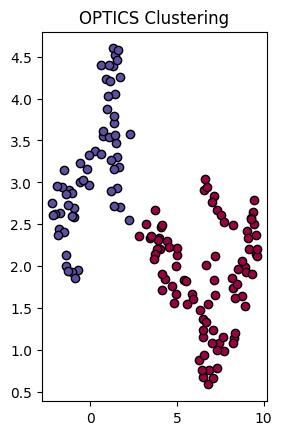

In [83]:
# 聚类结果
plt.subplot(122)
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = (0, 0, 0, 1)  # 黑色表示噪声
    class_member_mask = (labels == k)
    xy = data_umap[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)
plt.title('OPTICS Clustering')
plt.show()

/home/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


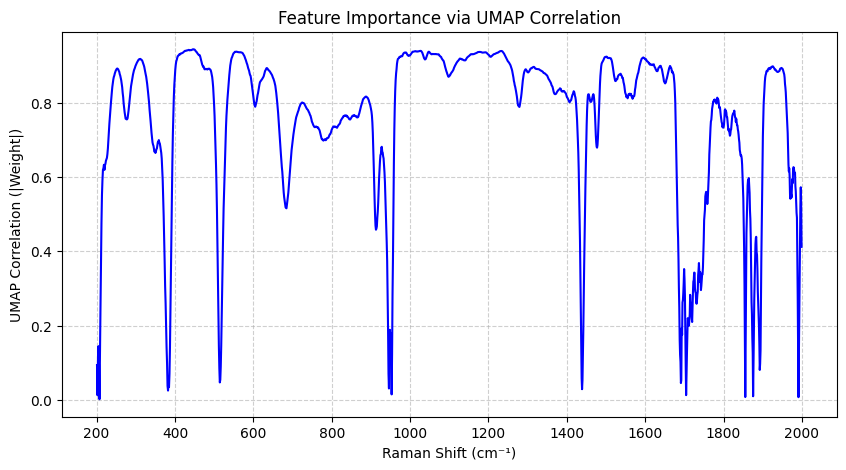

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# 1. 读取数据
header = pd.read_csv('denoised_spectra.csv', nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
df = pd.read_csv('denoised_spectra.csv', header=0)

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. UMAP降维
umap = UMAP(n_components=3, random_state=42)  # 通常使用2D可视化
embedding = umap.fit_transform(scaled_data)

# 4. 计算特征重要性（替代载荷）
# 方法1：通过特征与UMAP嵌入的相关性
feature_importance = np.array([
    np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1]  # 与第一UMAP维度的相关系数
    for i in range(scaled_data.shape[1])
])

# 方法2：使用UMAP的特征重要性（需要安装umap-learn>=0.5.0）
# feature_importance = umap.feature_importances_  # 如果可用

# 5. 可视化
plt.figure(figsize=(10, 5))
plt.plot(x_labels, np.abs(feature_importance), color='blue', linewidth=1.5)  # 取绝对值
# plt.title("Feature Importance via UMAP Correlation")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("UMAP Correlation (|Weight|)")
plt.xticks([200,400,600,800, 1000, 1200, 1400, 1600,1800,2000])
plt.grid(linestyle='--', alpha=0.6)
plt.show()


/home/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


图片已保存至: UMAP_variable.jpg


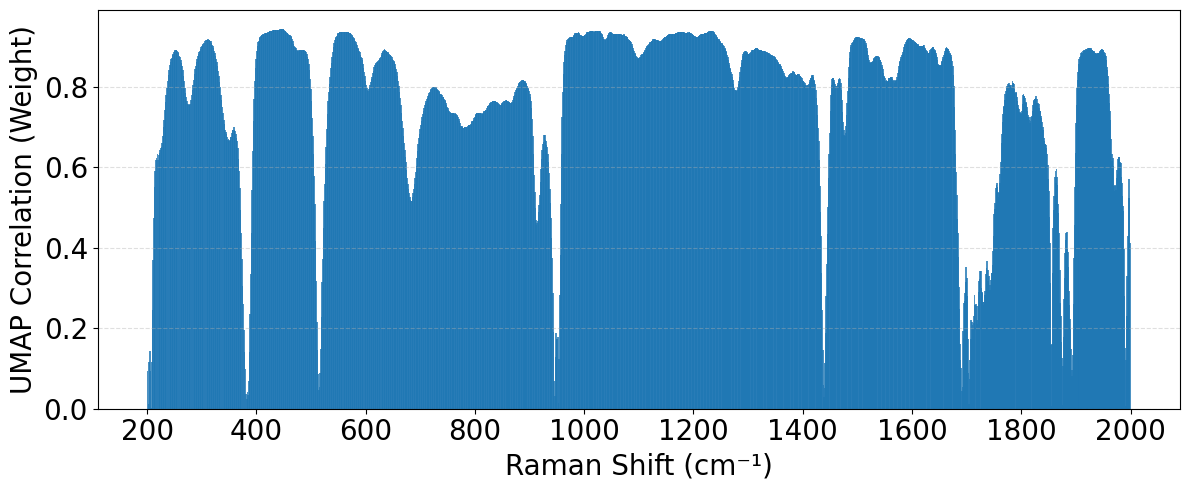

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# 1. 读取数据
header = pd.read_csv('denoised_spectra.csv', nrows=0).columns.tolist()
x_labels = np.array(header, dtype=float)
df = pd.read_csv('denoised_spectra.csv', header=0)

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. UMAP降维
umap = UMAP(n_components=3, random_state=42)
embedding = umap.fit_transform(scaled_data)

# 4. 计算特征重要性（绝对值）
feature_importance = np.array([
    np.abs(np.corrcoef(scaled_data[:, i], embedding[:, 0])[0, 1])
    for i in range(scaled_data.shape[1])
])

# 5. 可视化设置（字号修改部分）
plt.figure(figsize=(12, 5))

# 绘制柱状图
plt.bar(x_labels, feature_importance, 
        width=3.0,
        linewidth=0.5,
        alpha=0.8)

# 坐标轴标签字号设置
plt.xlabel("Raman Shift (cm⁻¹)", fontsize=20)  # 从12改为20
plt.ylabel("UMAP Correlation (Weight)", fontsize=20)  # 从12改为20

# 刻度字号设置
plt.xticks([200,400,600,800,1000,1200,1400,1600,1800,2000], 
          fontsize=20)  # 添加字号参数
plt.yticks(fontsize=20)  # 添加y轴字号设置

# 网格线保持原样
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# 保存图片
save_path = "UMAP_variable.jpg"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"图片已保存至: {save_path}")
plt.show()
